In [111]:
#Read Data 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns             

In [112]:
data = pd.read_csv("IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [113]:
data = data.rename(columns={'review': 'text'})

In [114]:

data.head()

,text,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [115]:
data.sentiment.unique()

array(['positive', 'negative'], dtype=object)

In [116]:
data.shape

(50000, 2)

In [117]:
data.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [118]:
data["sentiment"] = data["sentiment"].map({
    "positive":1,
    "negative":0
    })

In [119]:
data.head()

,text,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [120]:
text=data.iloc[2,0]
text

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

In [121]:
text = data.loc[2,"text"]
text

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

In [122]:
data.iloc[:10,:]

,text,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
5,"Probably my all-time favorite movie, a story o...",1
6,I sure would like to see a resurrection of a u...,1
7,"This show was an amazing, fresh & innovative i...",0
8,Encouraged by the positive comments about this...,0
9,If you like original gut wrenching laughter yo...,1


<Axes: xlabel='sentiment'>

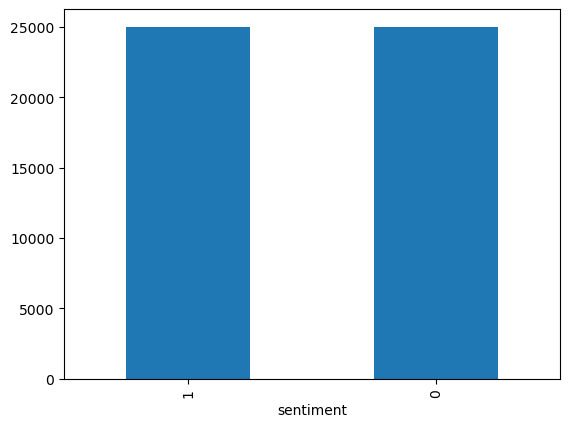

In [123]:
data['sentiment'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'label distribution')

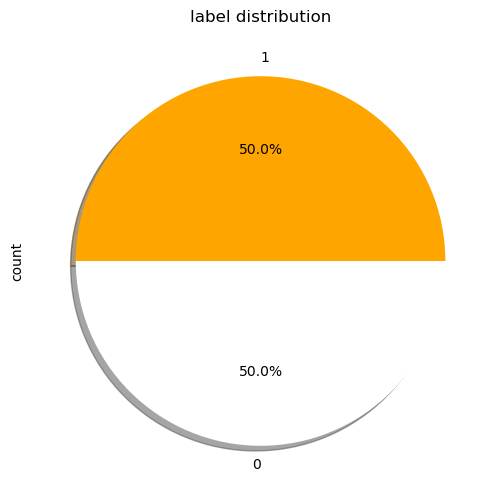

In [124]:
plt.figure(figsize=(10,6))
colors = ["orange","white"]
data['sentiment'].value_counts().plot(kind='pie',autopct='%.1f%%',shadow=True,colors=colors)
plt.title('label distribution')

Working With Text


In [125]:
data['text'][110]

'Apparently, the people that wrote the back of the box did not bother to watch this so-called "movie." They described "blindingly choreographed intrigue and violence." I saw no "intrigue." I instead saw a miserable attempt at dialogue in a supposed kung fu movie. I saw no "violence." At least, I saw nothing which could cause me to suspend my disbelief as to what could possibly hurt a man with "impervious" skin--but here I am perhaps revealing too much of the "plot." Furthermore, as a viewer of many and sundry films (some of which include the occasional kung fu movie), I can authoritatively say that this piece of celluloid is unwatchable. Whatever you may choose to do, I will always remain<br /><br /> Correct,<br /><br /> Jonathan Tanner <br /><br /> <br /><br />P.S. I was not blinded by the choreography.'

Cleaning Steps:
removing HTML Tags
extracting emojies # The pattern re.compile('(?::|;|=)(?:-)?(?:)|(|D|P)') is a regular expression used to match and extract emojis from a given text.
removing special chars,puntuation,sumbols
lower casing
removing stopwords
tokenization

In [126]:
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

# Stopwords set load karein
stopwords_set = set(stopwords.words('english'))

# --- YE NAYA LOGIC HAI ---
# In words ko stopwords list se nikal rahe hain taaki model 'don't' aur 'not' ko pehchane
negation_words = {'not', 'no', 'don', "don't", 'never', 'neither', 'nor'}
stopwords_set = stopwords_set - negation_words
# -------------------------

emoji_pattern = re.compile(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)')

def preprocessing(text):
    text = re.sub(r'<[^>]*>', '', text)
    emojis = emoji_pattern.findall(text)
    text = re.sub(r'[\W+]', ' ', text.lower()) + ' '.join(emojis).replace('-', '')
    
    porter = PorterStemmer()
    # Ab 'word not in stopwords_set' mein negation words check honge
    text = [porter.stem(word) for word in text.split() if word not in stopwords_set]
    
    return " ".join(text)

In [127]:
preprocessing('Apparently, the people that wrote the back of the box did not bother to watch this so-called "movie." They described "blindingly choreographed intrigue and violence." I saw no "intrigue." I instead saw a miserable attempt at dialogue in a supposed kung fu movie. I saw no "violence." At least, I saw nothing which could cause me to suspend my disbelief as to what could possibly hurt a man with "impervious" skin--but here I am perhaps revealing too much of the "plot." Furthermore, as a viewer of many and sundry films (some of which include the occasional kung fu movie), I can authoritatively say that this piece of celluloid is unwatchable. Whatever you may choose to do, I will always remain<br /><br /> Correct,<br /><br /> Jonathan Tanner <br /><br /> <br /><br />P.S. I was not blinded by the choreography.')

'appar peopl wrote back box not bother watch call movi describ blindingli choreograph intrigu violenc saw no intrigu instead saw miser attempt dialogu suppos kung fu movi saw no violenc least saw noth could caus suspend disbelief could possibl hurt man impervi skin perhap reveal much plot furthermor viewer mani sundri film includ occasion kung fu movi authorit say piec celluloid unwatch whatev may choos alway remain correct jonathan tanner p not blind choreographi'

In [128]:
preprocessing ('this is my tag <h1> :) <p>hello world<p> <div> <div> </h2>')

'tag hello world :)'

In [129]:
data['text'] = data['text'].apply(lambda x : preprocessing(x))

In [130]:
data['text'].head()

0    one review mention watch 1 oz episod hook righ...
1    wonder littl product film techniqu unassum old...
2    thought wonder way spend time hot summer weeke...
3    basic famili littl boy jake think zombi closet...
4    petter mattei love time money visual stun film...
Name: text, dtype: object

Visualizing Negative and Positive Words

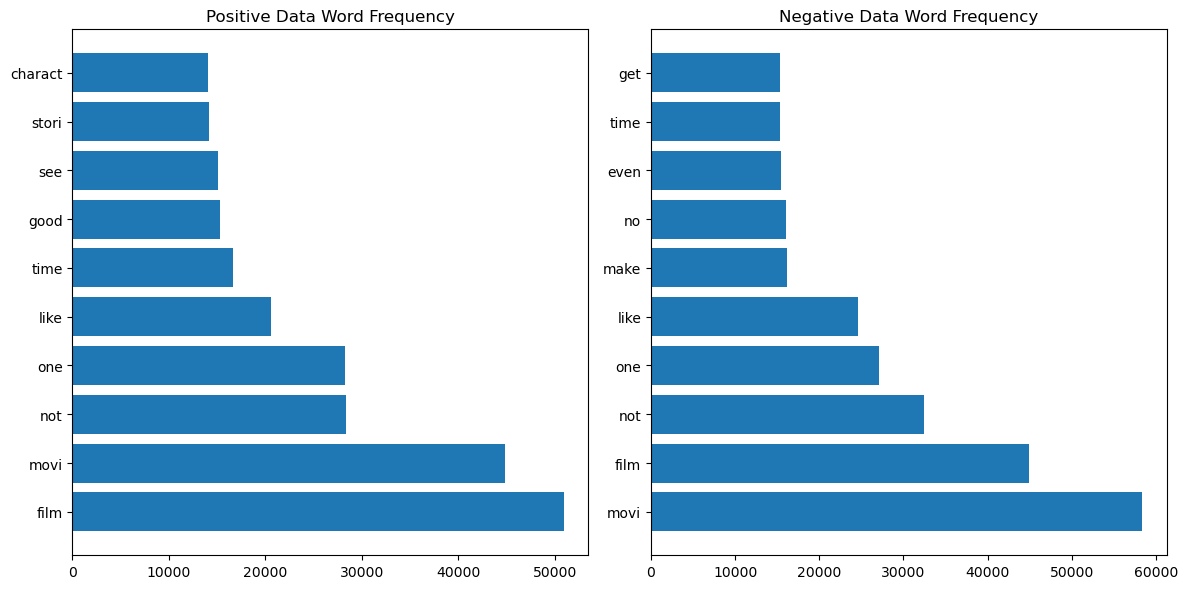

In [131]:
positivedata =data[data['sentiment'] == 1]
positivedata = positivedata['text']
negdata = data[data['sentiment'] == 0]
negdata = negdata['text']

import matplotlib.pyplot as plt 
from collections import Counter

#Positive data
positivedata_words = " ".join(positivedata).split()
positivedata_word_counts = Counter(positivedata_words)
positivedata_common_words = positivedata_word_counts.most_common(10)

#Negative data
negdata_words = " ".join(negdata).split()
negdata_word_counts = Counter(negdata_words)
negdata_common_words = negdata_word_counts.most_common(10)

#plotting

fig,axes = plt.subplots(1,2,figsize=(12,6))

# Positive data word frequency
axes[0].barh(range(len(positivedata_common_words)), [count for _, count in positivedata_common_words], align='center')
axes[0].set_yticks(range(len(positivedata_common_words)))
axes[0].set_yticklabels([word for word, _ in positivedata_common_words])
axes[0].set_title('Positive Data Word Frequency')

# Negative data word frequency
axes[1].barh(range(len(negdata_common_words)), [count for _, count in negdata_common_words], align='center')
axes[1].set_yticks(range(len(negdata_common_words)))
axes[1].set_yticklabels([word for word, _ in negdata_common_words])
axes[1].set_title('Negative Data Word Frequency')

plt.tight_layout()
plt.show()

TF-IDF Vectorizer to convert the raw documents into feature matrix

In [132]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features=5000 isliye taaki model sirf top important words/pairs le
# min_df=5 isliye taaki bahut rare words nikal jayein aur accuracy badhe
tfidf = TfidfVectorizer(ngram_range=(1, 2), 
                        max_features=5000, 
                        min_df=5,
                        stop_words=None) # Stopwords hum preprocessing mein handle kar rahe hain

y = data.sentiment.values
x = tfidf.fit_transform(data.text)

Training Machine Learning Model for Sentiment Analysis

In [133]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=1,test_size = 0.2,shuffle=False)

In [134]:


from sklearn.linear_model import LogisticRegression

# CV ki jagah simple Logistic Regression use karein memory bachane ke liye
clf = LogisticRegression(max_iter=1000, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Accuracy

In [135]:
from sklearn import metrics

# Model accuracy, how often is the classifier correct

print("Accuracy:",metrics.accuracy_score(y_test,y_pred))

Accuracy: 0.8917


In [136]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [137]:
# Data split
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1, test_size=0.2, shuffle=False)

In [138]:
# n_estimators=200 se model zyada trees use karega better patterns ke liye
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [139]:
# Accuracy check
y_pred = rf.predict(X_test)
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")

Accuracy: 0.8582


In [140]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4993
           1       0.86      0.86      0.86      5007

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



Pickle Files

In [141]:
import pickle

# Purani files ko overwrite kar rahe hain
pickle.dump(rf, open('clf.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))

print("Files saved successfully! Now replace them in your Streamlit folder.")

Files saved successfully! Now replace them in your Streamlit folder.


Prediction

In [142]:
def prediction(comment):
    preprocessed_comment = preprocessing(comment)
    comment_list = [preprocessed_comment]
    comment_vector = tfidf.transform(comment_list)
    prediction = clf.predict(comment_vector)[0]
    return prediction

prediction = prediction('What a great day!!! Looks like dream.')

In [143]:
prediction

1

In [144]:
if prediction == 0:
    print("Negative Comment")
else:
    print("Positive comment")

Positive comment
